# 07A – SHAP Global Explainability (Enterprise)
Professional Explainable AI notebook for Bankruptcy Risk Prediction.

## Business Objective
Explain the global behavior of the trained bankruptcy prediction model using SHAP and derive business insights for stakeholders.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.model_selection import train_test_split
from pathlib import Path

In [2]:
# Configuration
MODEL_PATH='../models/production_bankruptcy_model.joblib'
DATA_PATH='../data/datasets/american_bankruptcy.csv'
SAMPLE_SIZE=50

In [3]:
# Load model & data
model=joblib.load(MODEL_PATH)
df=pd.read_csv(DATA_PATH)

if 'status_label' in df.columns:
    y=df['status_label'].map({'alive':0,'failed':1})
    X=df.drop(columns=[c for c in ['status_label','company_name'] if c in df.columns])
elif 'target' in df.columns:
    y=df['target']
    X=df.drop(columns=[c for c in ['target','company_name'] if c in df.columns])
else:
    raise ValueError('Target column not found')

_,X_test,_,_=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

X_sample=X_test.sample(min(SAMPLE_SIZE,len(X_test)),random_state=42)
print(X_sample.shape)

(50, 19)


In [4]:
# Create SHAP explainer
predict_fn=lambda d:model.predict_proba(d)[:,1] if hasattr(model,'predict_proba') else model.predict(d)
explainer=shap.Explainer(predict_fn,X_sample)
shap_values=explainer(X_sample)

PermutationExplainer explainer:  14%|█▍        | 7/50 [00:00<?, ?it/s]

PermutationExplainer explainer:  18%|█▊        | 9/50 [00:10<00:08,  4.97it/s]

PermutationExplainer explainer:  20%|██        | 10/50 [00:11<00:11,  3.39it/s]

PermutationExplainer explainer:  22%|██▏       | 11/50 [00:11<00:13,  2.99it/s]

PermutationExplainer explainer:  24%|██▍       | 12/50 [00:11<00:14,  2.71it/s]

...

PermutationExplainer explainer:  96%|█████████▌| 48/50 [00:27<00:00,  2.30it/s]

PermutationExplainer explainer:  98%|█████████▊| 49/50 [00:27<00:00,  2.29it/s]

PermutationExplainer explainer: 100%|██████████| 50/50 [00:28<00:00,  2.29it/s]

PermutationExplainer explainer: 51it [00:28,  2.37it/s]                        

PermutationExplainer explainer: 51it [00:28,  1.54it/s]

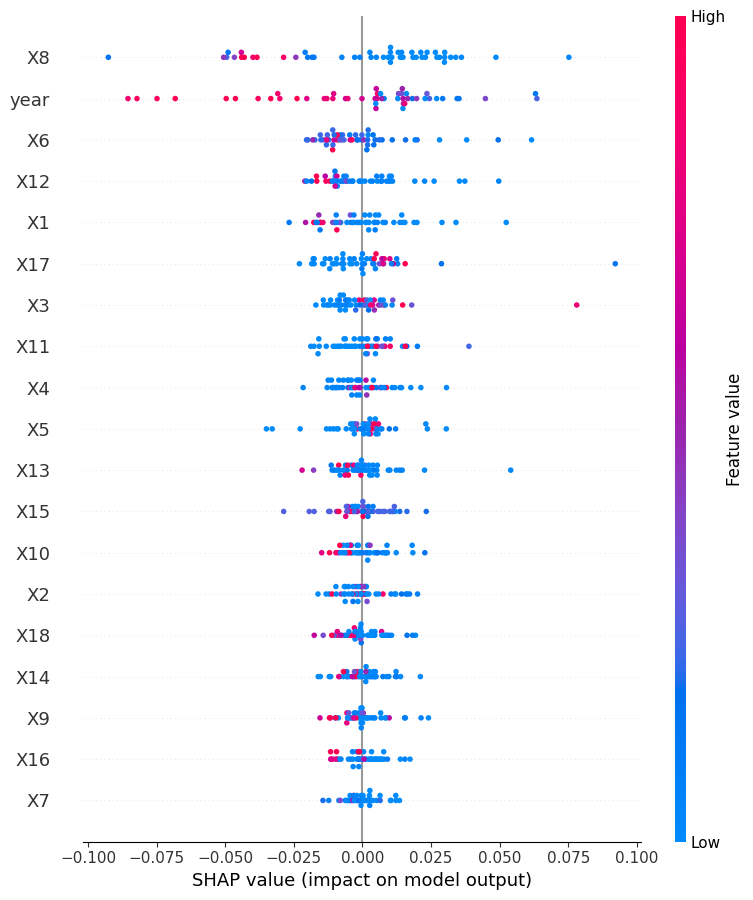

In [5]:
# SHAP Summary Plot
plt.figure(figsize=(10,6))
shap.plots.beeswarm(shap_values,max_display=20,show=False)
plt.tight_layout()
plt.savefig('shap_summary.png',dpi=300)
plt.show()

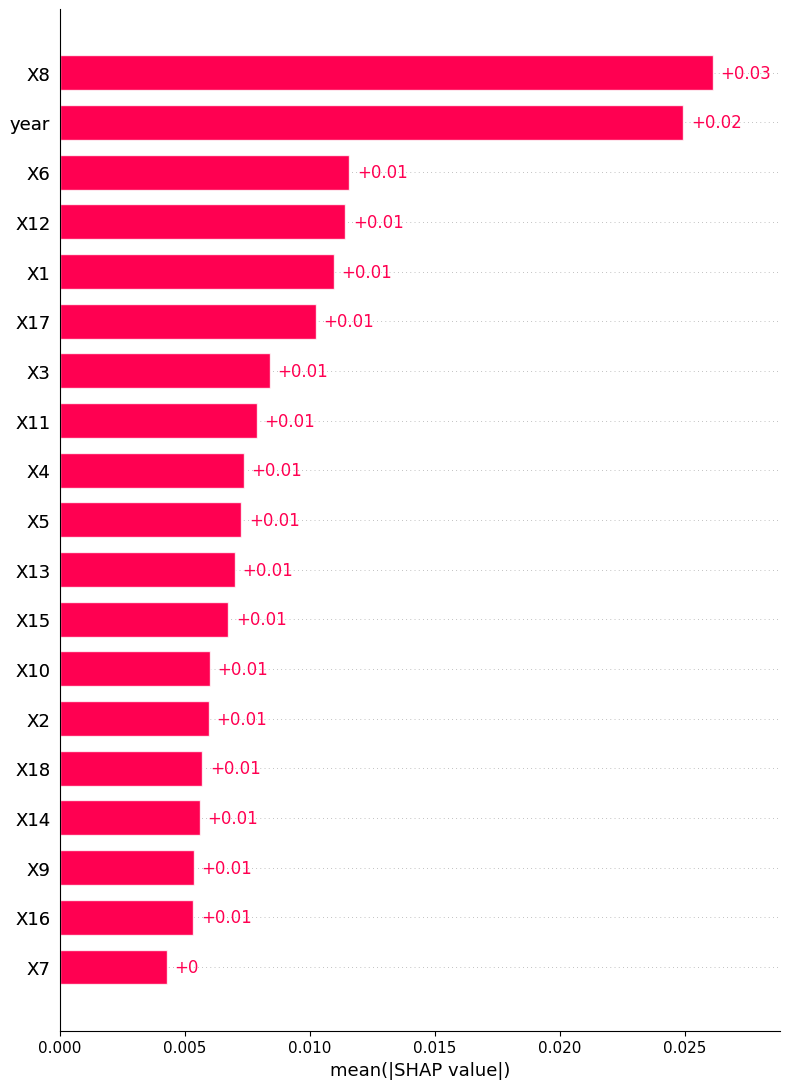

In [6]:
# SHAP Bar Plot
plt.figure(figsize=(10,6))
shap.plots.bar(shap_values,max_display=20,show=False)
plt.tight_layout()
plt.savefig('shap_bar.png',dpi=300)
plt.show()

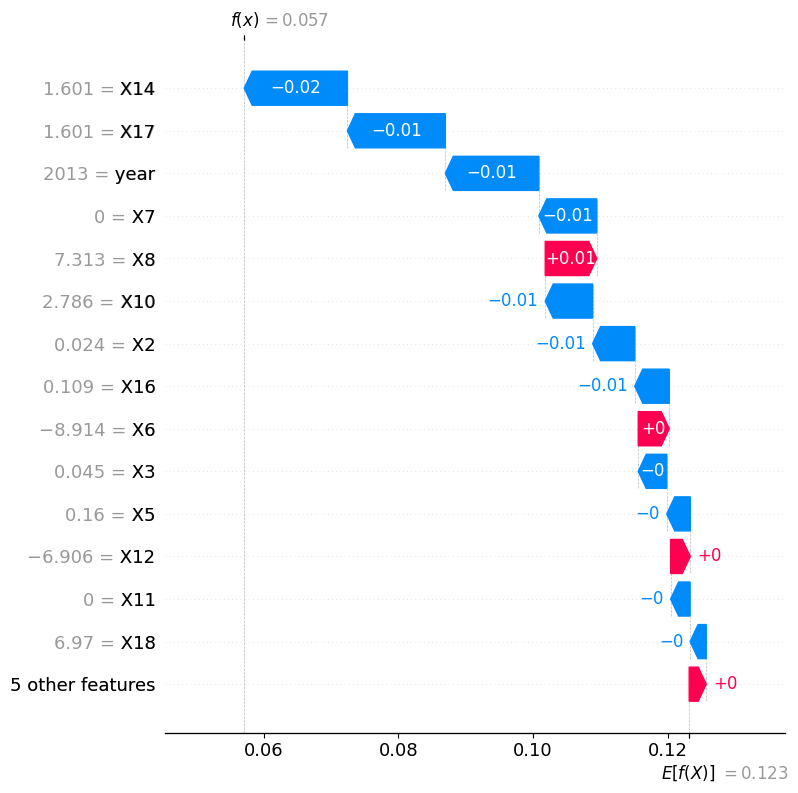

In [7]:
# Waterfall Plot
shap.plots.waterfall(shap_values[0],max_display=15,show=True)

In [8]:
# Global Feature Importance
importance=pd.DataFrame({
    'Feature':X_sample.columns,
    'MeanAbsSHAP':np.abs(shap_values.values).mean(axis=0)
}).sort_values('MeanAbsSHAP',ascending=False)

importance.to_csv('shap_global_feature_importance.csv',index=False)
importance.head(20)

,Feature,MeanAbsSHAP
8,X8,0.026140
0,year,0.024953
6,X6,0.011585
12,X12,0.011411
1,X1,0.010959
17,X17,0.010247
3,X3,0.008392
11,X11,0.007883
4,X4,0.007345
5,X5,0.007250


## Business Interpretation

- Features with the highest mean absolute SHAP values have the strongest influence on bankruptcy predictions.
- Positive SHAP values increase predicted bankruptcy risk.
- Negative SHAP values reduce predicted bankruptcy risk.
- Use these insights to prioritize financial risk indicators during credit assessment.

## Executive Summary

### Deliverables
- `shap_summary.png`
- `shap_bar.png`
- `shap_global_feature_importance.csv`

### Portfolio Value
This notebook demonstrates enterprise-grade Explainable AI practices and is suitable for inclusion in a professional data science portfolio.